In [14]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

In [65]:
path = ('./IART_9_clustering.xlsx')
xl = pd.read_excel(path, "catalog")
for i in xl.columns:
    print(i)
    

ID
Total LTD Orders
Total 24 Month Orders
Number of Divisns w/ Purchase
Number of Credit Cards Used
Customer Gender
Different Day/Night Phone (yes=1)
Dwelling Type Indicator
Overall RFM Points
First Purch Mail Order (yes=1)


/opt/homebrew/Caskroom/miniconda/base/envs/IA/lib/python3.10/site-packages/openpyxl/worksheet/_reader.py:329: UserWarning: Unknown extension is not supported and will be removed
  warn(msg)


In [71]:
features = [
    'Total LTD Orders', 
    'Total 24 Month Orders',
    'Number of Divisns w/ Purchase', 
    'Number of Credit Cards Used',
    'Different Day/Night Phone (yes=1)', 
    'Overall RFM Points',
    'First Purch Mail Order (yes=1)'
]
X = xl[features]

In [72]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

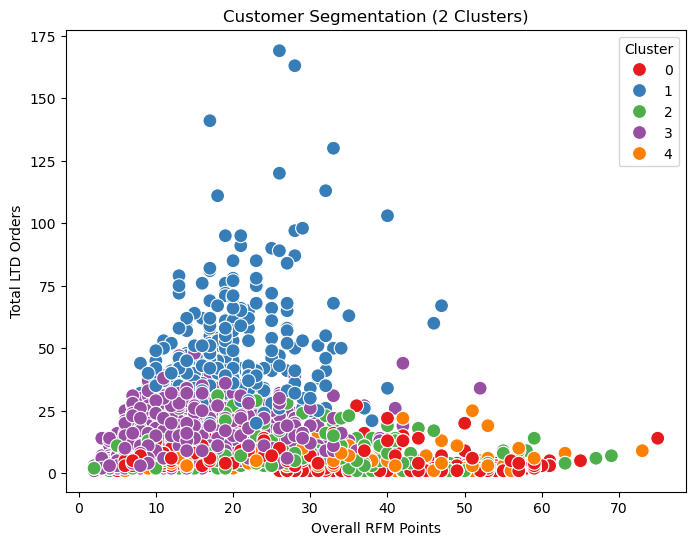

In [84]:
kmeans = KMeans(n_clusters=5, random_state=42, n_init='auto')
kmeans.fit(X_scaled)

# 6. Save the cluster labels back into your original dataframe
xl['Cluster'] = kmeans.labels_

# 7. Visualize the clusters using two main business metrics
plt.figure(figsize=(8, 6))
sns.scatterplot(
    x=xl['Overall RFM Points'], 
    y=xl['Total LTD Orders'], 
    hue=xl['Cluster'], 
    palette='Set1',
    s=100
)

plt.title('Customer Segmentation (2 Clusters)')
plt.xlabel('Overall RFM Points')
plt.ylabel('Total LTD Orders')
plt.show()

In [85]:
cluster_profiles = xl.groupby('Cluster')[features].mean()
print(cluster_profiles.T)

Cluster                                    0          1          2          3  \
Total LTD Orders                    1.566800  47.768730   3.293760  14.366154   
Total 24 Month Orders               1.267697   9.195440   1.420091   2.023077   
Number of Divisns w/ Purchase       1.095214  11.853420   1.414003   5.363846   
Number of Credit Cards Used         1.042871   2.208469   0.382040   2.067692   
Different Day/Night Phone (yes=1)   0.000000   0.296417   0.089802   0.362308   
Overall RFM Points                 39.472582  19.635179  36.098935  13.488462   
First Purch Mail Order (yes=1)      0.001496   0.876221   1.000000   0.823846   

Cluster                                    4  
Total LTD Orders                    1.768335  
Total 24 Month Orders               1.284051  
Number of Divisns w/ Purchase       1.116414  
Number of Credit Cards Used         1.057043  
Different Day/Night Phone (yes=1)   1.000000  
Overall RFM Points                 40.034924  
First Purch Mail Order

In [61]:
Total LTD Orders 1.710572 20.542891
Total 24 Month Orders 1.249856 3.422316
Number of Divisns w/ Purchase 1.112363 6.506299
Number of Credit Cards Used 0.932987 2.031794
Different Day/Night Phone (yes=1) 0.262276 0.343131
Overall RFM Points 39.215194 15.050390
First Purch Mail Order (yes=1) 0.185153 0.850030

Cluster                                    0          1          2          3
Total LTD Orders                    1.498741  47.768730   3.461538  14.222474
Total 24 Month Orders               1.250989   9.195440   1.483916   2.012821
Number of Divisns w/ Purchase       1.077670  11.853420   1.418182   5.314480
Number of Credit Cards Used         1.039914   2.208469   0.437762   2.061840
Different Day/Night Phone (yes=1)   0.281913   0.296417   0.160839   0.369532
Overall RFM Points                 39.883855  19.635179  36.288112  13.545249
First Purch Mail Order (yes=1)      0.001079   0.876221   1.000000   0.807692


Cluster                                       0             1
ID                                 54658.008333  57131.526734
Total LTD Orders                       1.363580     18.924828
Total 24 Month Orders                  1.243210      3.178401
Number of Divisns w/ Purchase          1.042284      5.992589
Number of Credit Cards Used            0.907716      1.946003
Customer Gender                        0.885185      0.875596
Different Day/Night Phone (yes=1)      0.262037      0.334039
Dwelling Type Indicator                1.000000      0.916358
Overall RFM Points                    40.520370     15.651668
First Purch Mail Order (yes=1)         0.166667      0.803600

Cluster                                       0             1
ID                                 54862.818730  57060.636529
Total LTD Orders                       1.732548     20.713592
Total 24 Month Orders                  1.251939      3.442961
Number of Divisns w/ Purchase          1.117495      6.557646
Number of Credit Cards Used            0.934214      2.041869
Customer Gender                        0.882505      0.879854
Different Day/Night Phone (yes=1)      0.262281      0.344053
Dwelling Type Indicator                0.993680      0.917476
Overall RFM Points                    39.075840     15.066141
First Purch Mail Order (yes=1)         0.188164      0.851335

SyntaxError: invalid syntax (742305129.py, line 1)